# Gear Fault Classification from Vibration Signals Using Machine Learning

## Goal
Classify six gear conditions (one normal and five defective) using x- and
y-axis vibration measurements from the
[Mechanical Gear Vibration dataset](https://www.kaggle.com/datasets/hieudaotrung/gear-vibration).

**Status:** Prepared workflow; no measured results have been generated yet.
Run all cells with the real dataset to populate the comparisons and final write-up.
Dataset layout, condition names, sensor units, and sampling frequency must be
confirmed from the downloaded data. No accuracy values or fault signatures are invented.

## Context & Methods
Extract mean, sample standard deviation, RMS, absolute peak, bias-corrected
skewness, and Fisher excess kurtosis from each axis: twelve features per window.
Compare Logistic Regression, Linear SVM, Decision Tree, Random Forest and XGBoost.

### Key Assumptions
- Each configured file contains one condition; row order is acquisition order.
- Contiguous changes in operating conditions and timestamp resets start new runs.
  Configure metadata columns below; do not concatenate separate runs blindly.
- Split each run chronologically into 60% training, 20% validation, 20% testing
  before windowing, with one window-length embargo at each boundary.
- Windows may overlap within a partition but never share samples across partitions.
  Serial dependence can remain; this is a within-recording benchmark, not a test
  on independent machines. Use session-level holdouts when session metadata exists.
- Window length is in samples. Set it using the confirmed sample rate and enough
  shaft revolutions; the default 1024 is an initial experiment parameter.

## Setup
Install `requirements.txt` using the README command. Place extracted CSV files
in `data/`, or enable the Kaggle download below (internet and possibly Kaggle
authentication are required). Run from this project folder.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import os
import platform
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from IPython.display import display, Markdown

SEED = 42
DATA_DIR = Path('data')
OUTPUT_DIR = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)
DOWNLOAD_DATA = True   # set False if the data is already in DATA_DIR

if DOWNLOAD_DATA:
    # --- Kaggle credentials via kaggle.json upload (Colab) ---
    from google.colab import files
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_json = kaggle_dir / 'kaggle.json'

    if not kaggle_json.exists():
        print('Upload your kaggle.json file...')
        uploaded = files.upload()              # opens the file picker
        assert 'kaggle.json' in uploaded, 'Please upload a file named kaggle.json'
        kaggle_dir.mkdir(exist_ok=True)
        kaggle_json.write_bytes(uploaded['kaggle.json'])
        kaggle_json.chmod(0o600)               # Kaggle requires restricted permissions

    # Also expose credentials as env vars (used by kagglehub / kaggle API)
    creds = json.loads(kaggle_json.read_text())
    os.environ['KAGGLE_USERNAME'] = creds['username']
    os.environ['KAGGLE_KEY'] = creds['key']

    # --- Download dataset ---
    import kagglehub
    DATA_DIR = Path(kagglehub.dataset_download('hieudaotrung/gear-vibration'))
    print('Dataset downloaded to:', DATA_DIR)

plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

Upload your kaggle.json file...


Saving kaggle.json to kaggle.json


100%|██████████| 8.47M/8.47M [00:00<00:00, 76.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/hieudaotrung/gear-vibration/versions/1


## Data
### 1. Inspect Files
This preview exposes headers before configuration. CSV delimiter detection is
enabled; change `CSV_OPTIONS` if the source uses different headers or decimal notation.

In [2]:
CSV_OPTIONS = {'sep': None, 'engine': 'python'}
files = sorted(DATA_DIR.rglob('*.csv'))
if not files:
    raise FileNotFoundError('No CSV files found. Extract the Kaggle dataset into data/ or enable DOWNLOAD_DATA.')
for path in files:
    preview = pd.read_csv(path, nrows=3, **CSV_OPTIONS)
    print(path.relative_to(DATA_DIR).as_posix(), ':', list(preview.columns))
    display(preview)


eccentricity.csv : ['sensor1', 'sensor2', 'time_x', 'speedSet', 'load_value', 'gear_fault_desc']


,sensor1,sensor2,time_x,speedSet,load_value,gear_fault_desc
0,2.522315,2.431974,2023-05-03 20:31:39.000000,8.332031,0,eccentricity
1,2.523629,2.431317,2023-05-03 20:31:39.000200,8.332031,0,eccentricity
2,2.522644,2.428032,2023-05-03 20:31:39.000400,8.332031,0,eccentricity


missing_tooth.csv : ['sensor1', 'sensor2', 'time_x', 'speedSet', 'load_value', 'gear_fault_desc']


,sensor1,sensor2,time_x,speedSet,load_value,gear_fault_desc
0,2.520016,2.430496,2023-05-03 13:06:37.000000,8.332031,0,missing tooth
1,2.521822,2.430660,2023-05-03 13:06:37.000200,8.332031,0,missing tooth
2,2.519194,2.429511,2023-05-03 13:06:37.000400,8.332031,0,missing tooth


no_fault.csv : ['sensor1', 'sensor2', 'time_x', 'speedSet', 'load_value', 'gear_fault_desc']


...

,sensor1,sensor2,time_x,speedSet,load_value,gear_fault_desc
0,2.519358,2.429675,2023-05-03 14:41:31.000000,8.332031,0,Root crack
1,2.519358,2.429839,2023-05-03 14:41:31.000200,8.332031,0,Root crack
2,2.521165,2.430496,2023-05-03 14:41:31.000400,8.332031,0,Root crack


surface_fault.csv : ['sensor1', 'sensor2', 'time_x', 'speedSet', 'load_value', 'gear_fault_desc']


,sensor1,sensor2,time_x,speedSet,load_value,gear_fault_desc
0,2.521001,2.427539,2023-05-02 14:35:14.000000,8.332031,0,surface defect
1,2.519851,2.428196,2023-05-02 14:35:14.000200,8.332031,0,surface defect
2,2.520016,2.426225,2023-05-02 14:35:14.000400,8.332031,0,surface defect


tooth_chipped_fault.csv : ['sensor1', 'sensor2', 'time_x', 'speedSet', 'load_value', 'gear_fault_desc']


,sensor1,sensor2,time_x,speedSet,load_value,gear_fault_desc
0,2.518209,2.430496,2023-05-02 15:53:07.000000,8.332031,0,chipped tooth
1,2.517880,2.429839,2023-05-02 15:53:07.000200,8.332031,0,chipped tooth
2,2.516402,2.427211,2023-05-02 15:53:07.000400,8.332031,0,chipped tooth


### 2. Confirm Mapping
Set `SENSOR_COLUMNS` to the two exact vibration headers shown above, in x/y order.
Automatic detection accepts only explicit x/y or Sensor1/Sensor2 names.
Set `FILE_LABELS` using relative CSV paths and condition names from the dataset;
all six classes must be mapped. This avoids silently deriving labels from numbers.
Set `RUN_COLUMNS` to available speed, load, state or session fields, and
`TIME_COLUMN` to the timestamp field. Metadata is used only to identify boundaries,
never as model input. If metadata exists, leaving it out can mix acquisitions.

In [3]:
SENSOR_COLUMNS = ('sensor1', 'sensor2')
FILE_LABELS = {
    'eccentricity.csv': 'eccentricity',
    'missing_tooth.csv': 'missing tooth',
    'no_fault.csv': 'No fault',
    'root_crack.csv': 'Root crack',
    'surface_fault.csv': 'surface defect',
    'tooth_chipped_fault.csv': 'chipped tooth',
}
RUN_COLUMNS = ['speedSet', 'load_value']
TIME_COLUMN = 'time_x'
WINDOW_SIZE = 1024
HOP_SIZE = 512
GAP_SAMPLES = WINDOW_SIZE
EXPECTED_CLASSES = 6
assert WINDOW_SIZE >= 4 and 1 <= HOP_SIZE <= WINDOW_SIZE
assert GAP_SAMPLES >= WINDOW_SIZE

def normalize(text):
    return re.sub(r'[^a-z0-9]', '', str(text).lower())

def sensor_columns(frame):
    if SENSOR_COLUMNS is not None:
        columns = list(SENSOR_COLUMNS)
    else:
        names = {normalize(c): c for c in frame.columns}
        pairs = [('x', 'y'), ('sensor1', 'sensor2'), ('vibrationx', 'vibrationy')]
        matches = [[names[a], names[b]] for a, b in pairs if a in names and b in names]
        if len(matches) != 1:
            raise ValueError('Set SENSOR_COLUMNS explicitly after inspecting the CSV headers.')
        columns = matches[0]
    if len(columns) != 2 or len(set(columns)) != 2 or not set(columns) <= set(frame.columns):
        raise ValueError(f'Invalid sensor columns: {columns}')
    return columns

relative_paths = [p.relative_to(DATA_DIR).as_posix() for p in files]
if set(FILE_LABELS) != set(relative_paths):
    raise ValueError(f'Set FILE_LABELS for exactly these files: {relative_paths}')
if len(set(FILE_LABELS.values())) != EXPECTED_CLASSES:
    raise ValueError('Expected six distinct conditions. Verify the dataset and mapping.')


### 3. Extract Features Without Crossing Boundaries
Do not remove invalid rows and join the remaining samples: that would alter time.
Non-finite sensor values stop execution for source inspection. Constant windows
use zero skewness and excess kurtosis as an explicit computational convention.
Short runs that cannot supply a window in every partition stop execution.

In [4]:
STATISTICS = ['mean', 'std', 'rms', 'peak', 'skewness', 'kurtosis']
FEATURES = [f'{axis}_{stat}' for axis in ('x', 'y') for stat in STATISTICS]

def extract_features(window):
    values = []
    for signal in window.T:
        constant = np.ptp(signal) == 0
        values.extend([signal.mean(), signal.std(ddof=1),
                       np.sqrt(np.mean(signal ** 2)), np.max(np.abs(signal)),
                       0.0 if constant else skew(signal, bias=False),
                       0.0 if constant else kurtosis(signal, fisher=True, bias=False)])
    return dict(zip(FEATURES, values))

rows, inventory = [], []
seen_hashes = set()
for path in files:
    relative = path.relative_to(DATA_DIR).as_posix()
    with path.open('rb') as source_file:
        digest = hashlib.file_digest(source_file, 'sha256').hexdigest()
    if digest in seen_hashes:
        raise ValueError(f'Duplicate source file: {relative}')
    seen_hashes.add(digest)
    frame = pd.read_csv(path, **CSV_OPTIONS)
    columns = sensor_columns(frame)
    signal = frame[columns].apply(pd.to_numeric, errors='raise').to_numpy(dtype=float)
    if not np.isfinite(signal).all():
        raise ValueError(f'Non-finite sensor values in {relative}; inspect the original rows.')
    boundary = pd.Series(False, index=frame.index)
    for column in RUN_COLUMNS:
        if frame[column].isna().any():
            raise ValueError(f'Missing run metadata in {relative}: {column}')
        boundary |= frame[column].ne(frame[column].shift())
    if TIME_COLUMN is not None:
        timestamps = pd.to_datetime(frame[TIME_COLUMN], errors='raise',
                                    format='%Y-%m-%d %H:%M:%S.%f')
        if timestamps.isna().any():
            raise ValueError('Invalid timestamps.')
        steps = timestamps.diff().dt.total_seconds()
        typical_step = steps[steps > 0].median()
        boundary |= steps.le(0) | steps.gt(1.5 * typical_step)
    boundary.iloc[0] = True
    starts = np.flatnonzero(boundary.to_numpy())
    ends = np.r_[starts[1:], len(frame)]
    inventory.append({'file': relative, 'label': FILE_LABELS[relative],
                      'samples': len(frame), 'runs': len(starts), 'sha256': digest})
    for run_id, (run_start, run_end) in enumerate(zip(starts, ends)):
        length = run_end - run_start
        cut1, cut2 = int(length * .6), int(length * .8)
        partitions = {'train': (0, cut1), 'validation': (cut1 + GAP_SAMPLES, cut2),
                      'test': (cut2 + GAP_SAMPLES, length)}
        for split, (left, right) in partitions.items():
            if right - left < WINDOW_SIZE:
                raise ValueError(f'{relative}, run {run_id}, {split} is too short. Review boundaries/window size.')
            for offset in range(left, right - WINDOW_SIZE + 1, HOP_SIZE):
                start = int(run_start + offset)
                end = start + WINDOW_SIZE
                rows.append({'file': relative, 'run': run_id, 'label': FILE_LABELS[relative],
                             'split': split, 'start': start, 'end': end,
                             **extract_features(signal[start:end])})
features = pd.DataFrame(rows)
if not np.isfinite(features[FEATURES].to_numpy()).all():
    raise ValueError('Non-finite extracted features; inspect near-constant signals or numeric overflow.')
display(pd.DataFrame(inventory))
display(pd.crosstab(features['label'], features['split']))
features.to_csv(OUTPUT_DIR / 'window_features.csv', index=False)


,file,label,samples,runs,sha256
0,eccentricity.csv,eccentricity,150000,6,372aa6dbf0d0873c5ced5edd5d8e02977e90d7a4a9478b...
1,missing_tooth.csv,missing tooth,150000,6,74a9d3d5a7cd5394cc2668fc55523a16b2d7d71276bd80...
2,no_fault.csv,No fault,150000,6,6d3bbd3da1809363ac756e4d0aa186a2717e0d276ed4b7...
3,root_crack.csv,Root crack,150000,6,ec29bab88aa04c0a5a4fa2541281fd1b8eb1bc63d3ccc4...
4,surface_fault.csv,surface defect,150000,6,a0382ce9392ca30e43ddd2490ec8f6403b795ce0a61444...
5,tooth_chipped_fault.csv,chipped tooth,150000,6,307efe80d3464002e143f9a759402e69b0f2a9174f9f1f...


split,test,train,validation
label,,,
No fault,36,168,36
Root crack,36,168,36
chipped tooth,36,168,36
eccentricity,36,168,36
missing tooth,36,168,36
surface defect,36,168,36


### 4. Verify Separation
Check raw sample intervals, class coverage, and exact duplicate feature vectors
across partitions. Duplicate vectors can be legitimate but should be investigated.

In [5]:
for _, group in features.groupby(['file', 'run']):
    for first, second in [('train', 'validation'), ('validation', 'test')]:
        a = group.loc[group['split'].eq(first)]
        b = group.loc[group['split'].eq(second)]
        assert a['end'].max() + GAP_SAMPLES <= b['start'].min()
for split in ['train', 'validation', 'test']:
    assert features.loc[features['split'].eq(split), 'label'].nunique() == EXPECTED_CLASSES
hashes = pd.util.hash_pandas_object(features[FEATURES], index=False)
duplicate_splits = pd.DataFrame({'hash': hashes, 'split': features['split']}).groupby('hash')['split'].nunique()
print('Feature vectors appearing in multiple partitions:', int((duplicate_splits > 1).sum()))
print('PASS: no raw sample overlap across partitions in each source run.')

encoder = LabelEncoder().fit(features['label'])
datasets = {}
for split in ['train', 'validation', 'test']:
    subset = features.loc[features['split'].eq(split)]
    datasets[split] = (subset[FEATURES], encoder.transform(subset['label']))
X_train, y_train = datasets['train']
X_val, y_val = datasets['validation']
X_test, y_test = datasets['test']


Feature vectors appearing in multiple partitions: 0
PASS: no raw sample overlap across partitions in each source run.


## Results
### 5. Fit and Select Models
Scaling is fitted only on training data inside each linear-model pipeline.
Hyperparameters are fixed in advance. Select the model by validation macro-F1,
then validation accuracy. Do not change the selection after seeing test results.

In [6]:
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED)),
    'Linear SVM': make_pipeline(StandardScaler(), LinearSVC(dual=False, max_iter=20000, random_state=SEED)),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, min_samples_leaf=3, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=250, max_depth=4, learning_rate=.05,
                            subsample=.8, colsample_bytree=.8, objective='multi:softprob',
                            num_class=EXPECTED_CLASSES, eval_metric='mlogloss',
                            tree_method='hist', n_jobs=2, random_state=SEED)
}
validation_rows = []
for name, model in models.items():
    started = time.perf_counter()
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    validation_rows.append({'model': name, 'validation_accuracy': accuracy_score(y_val, pred),
                            'validation_macro_f1': f1_score(y_val, pred, average='macro'),
                            'fit_seconds': time.perf_counter() - started})
validation = pd.DataFrame(validation_rows).set_index('model').sort_values(
    ['validation_macro_f1', 'validation_accuracy'], ascending=False)
selected_name = validation.index[0]
display(validation.round(4))
print('Selected using validation only:', selected_name)


,validation_accuracy,validation_macro_f1,fit_seconds
model,,,
Random Forest,0.9769,0.9768,1.2806
XGBoost,0.9722,0.9722,1.0585
Decision Tree,0.9537,0.9537,0.0248
Linear SVM,0.7407,0.7163,0.0287
Logistic Regression,0.7315,0.7133,0.0667


Selected using validation only: Random Forest


### 6. Final Held-Out Comparison
Evaluate all five fixed models for the requested benchmark. Keep the validation
selection frozen. Accuracy counts correct windows; macro-F1 weights classes
equally. Overlapping windows are correlated, so window counts are not independent
sample sizes and naive binomial confidence intervals are not reported.

,validation_accuracy,validation_macro_f1,fit_seconds,test_accuracy,test_macro_f1
model,,,,,
Random Forest,0.9769,0.9768,1.2806,0.9722,0.9724
XGBoost,0.9722,0.9722,1.0585,0.9769,0.9770
Decision Tree,0.9537,0.9537,0.0248,0.9120,0.9118
Linear SVM,0.7407,0.7163,0.0287,0.7685,0.7514
Logistic Regression,0.7315,0.7133,0.0667,0.7593,0.7453


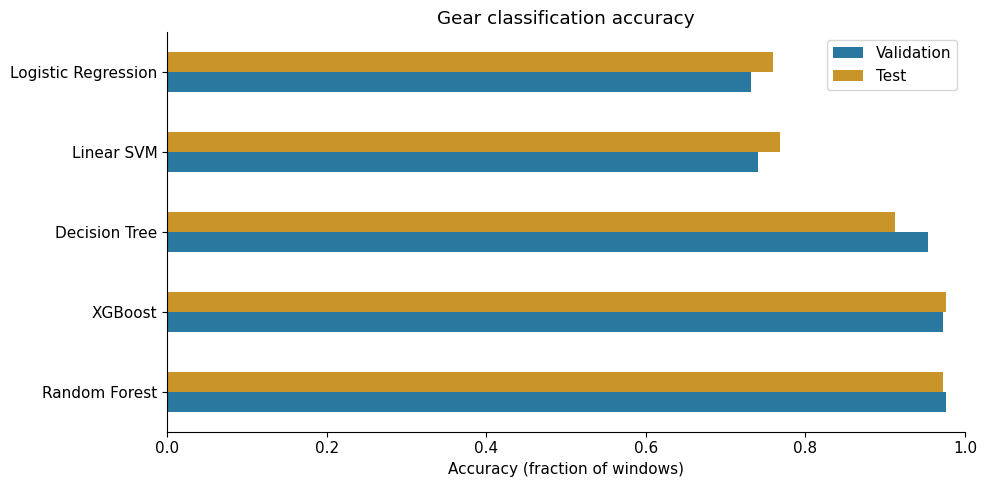

In [7]:
test_rows, predictions = [], {}
for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    test_rows.append({'model': name, 'test_accuracy': accuracy_score(y_test, pred),
                      'test_macro_f1': f1_score(y_test, pred, average='macro')})
results = validation.join(pd.DataFrame(test_rows).set_index('model'))
display(results.round(4))
results.to_csv(OUTPUT_DIR / 'model_comparison.csv')
prediction_table = features.loc[features['split'].eq('test'), ['file', 'run', 'start', 'end', 'label']].copy()
for name, pred in predictions.items():
    prediction_table[name] = encoder.inverse_transform(pred)
prediction_table.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 5))
results[['validation_accuracy', 'test_accuracy']].plot.barh(ax=ax, color=['#2878A0', '#C99529'])
ax.set(xlim=(0, 1), xlabel='Accuracy (fraction of windows)', ylabel='', title='Gear classification accuracy')
ax.legend(['Validation', 'Test'])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_comparison.png', dpi=160)
plt.show()


### 7. Confusion Matrices
Rows are true conditions; columns are predictions. Counts retain class support.
The classification report gives per-class precision, recall and F1 for the
validation-selected model.

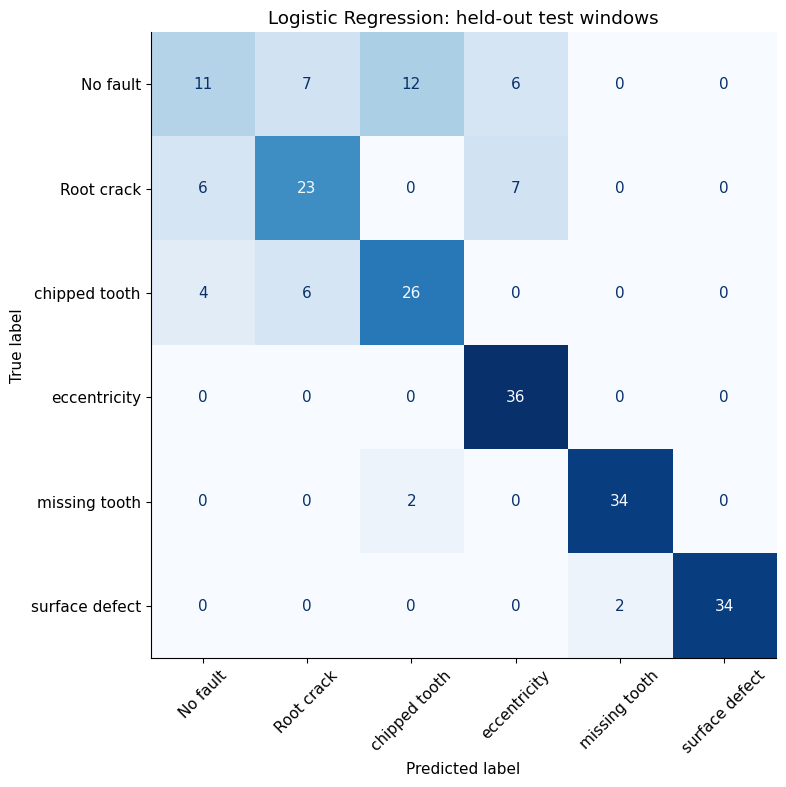

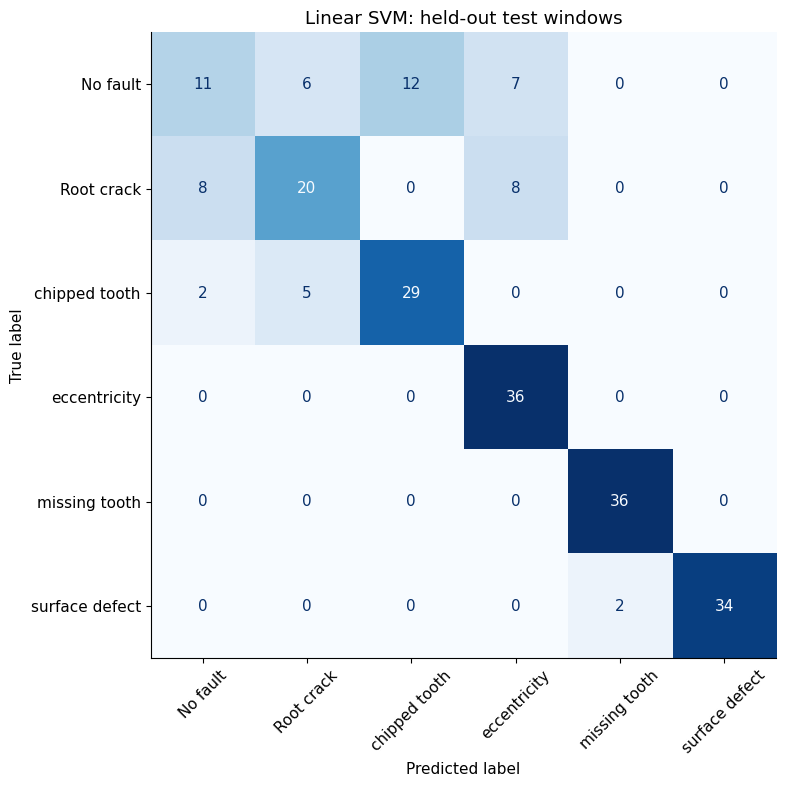

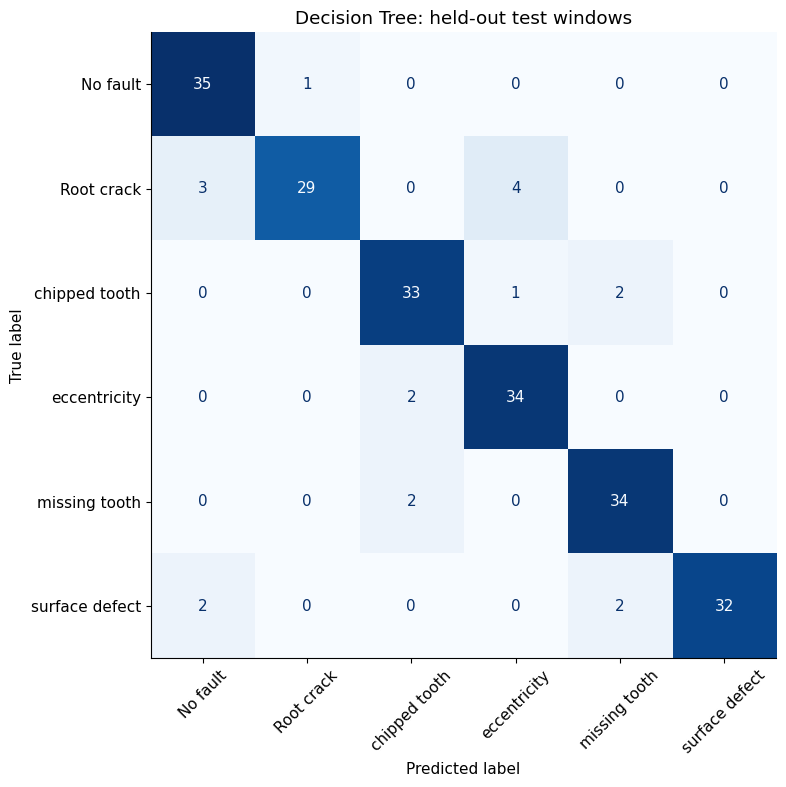

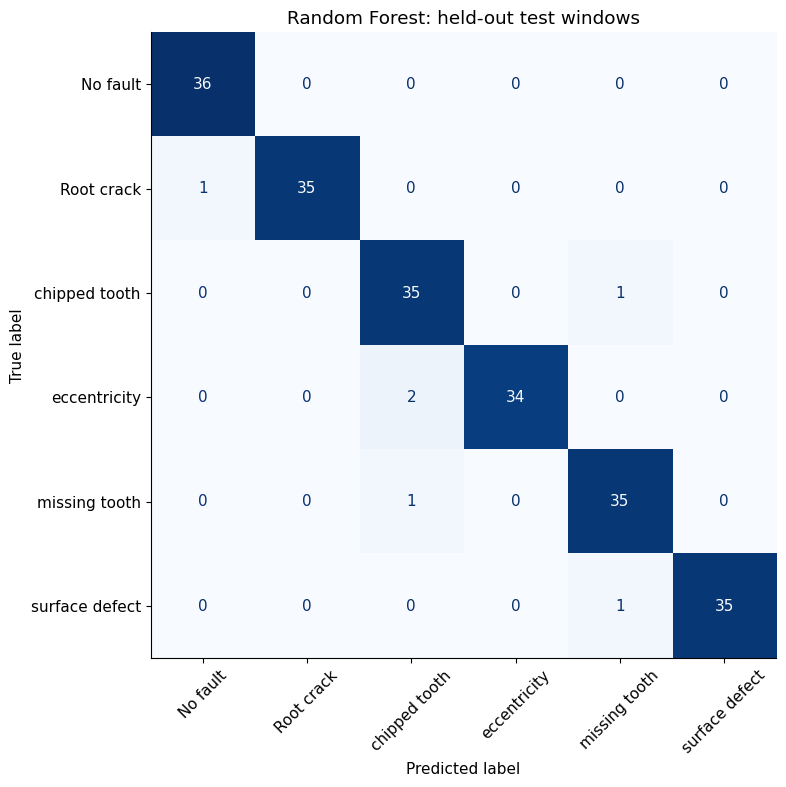

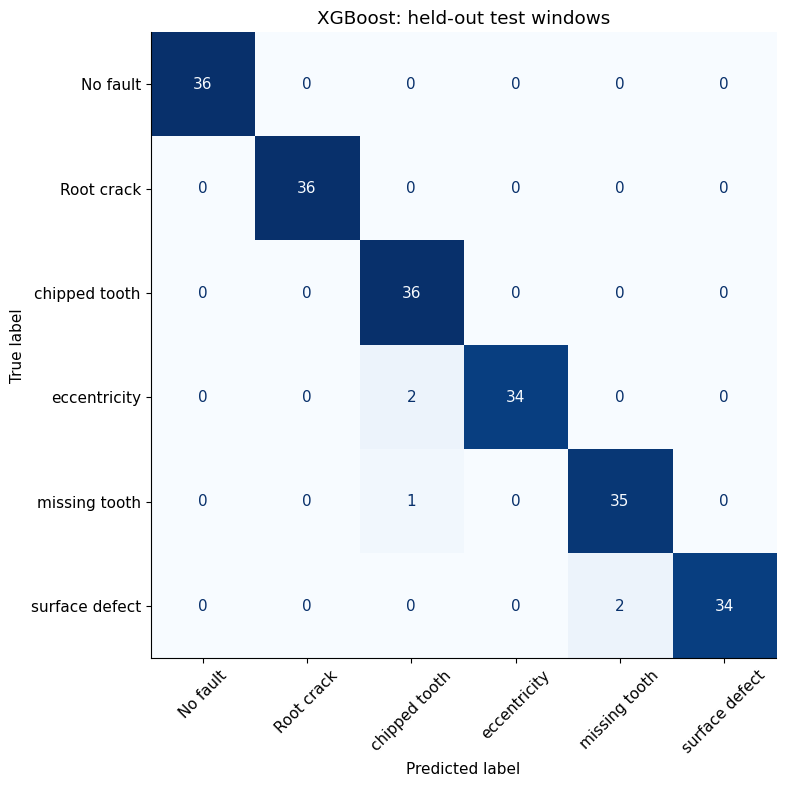

,precision,recall,f1-score,support
No fault,0.973,1.000,0.986,36.000
Root crack,1.000,0.972,0.986,36.000
chipped tooth,0.921,0.972,0.946,36.000
eccentricity,1.000,0.944,0.971,36.000
missing tooth,0.946,0.972,0.959,36.000
surface defect,1.000,0.972,0.986,36.000
accuracy,0.972,0.972,0.972,0.972
macro avg,0.973,0.972,0.972,216.000
weighted avg,0.973,0.972,0.972,216.000


In [8]:
for name, pred in predictions.items():
    fig, ax = plt.subplots(figsize=(9, 8))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=np.arange(EXPECTED_CLASSES),
        display_labels=encoder.classes_, cmap='Blues', colorbar=False, ax=ax, xticks_rotation=45)
    ax.set_title(f'{name}: held-out test windows')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / (normalize(name) + '_confusion.png'), dpi=160)
    plt.show()
report = classification_report(y_test, predictions[selected_name], labels=np.arange(EXPECTED_CLASSES),
                               target_names=encoder.classes_, output_dict=True, zero_division=0)
display(pd.DataFrame(report).T.round(3))
pd.DataFrame(report).T.to_csv(OUTPUT_DIR / 'selected_model_classification_report.csv')


### 8. Feature Importance
Permutation importance measures the decrease in validation macro-F1 after
shuffling a feature in the selected model. Bars show repeat-to-repeat standard
deviation, not confidence intervals. Correlated RMS and standard deviation can
share predictive information, reducing either feature's individual importance.
Random Forest impurity importance is also supplied, but can be biased and is not causal.

,feature,mean_drop,repeat_std
0,x_mean,0.2178,0.0232
8,y_rms,0.0658,0.0103
6,y_mean,0.0605,0.0094
2,x_rms,0.0318,0.0060
11,y_kurtosis,0.0297,0.0047
5,x_kurtosis,0.0154,0.0069
4,x_skewness,0.0000,0.0000
1,x_std,0.0000,0.0000
10,y_skewness,0.0000,0.0000
3,x_peak,0.0000,0.0000


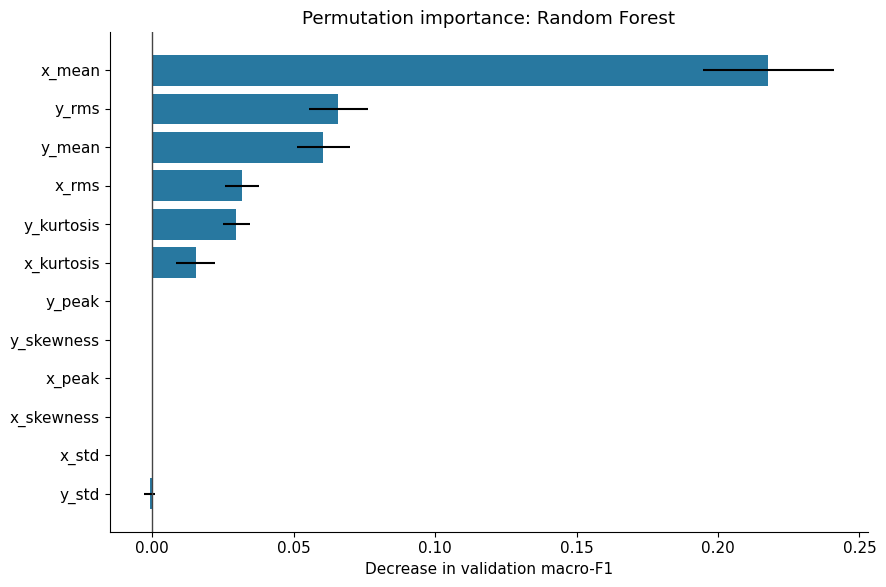

,Random Forest impurity importance
x_mean,0.174902
y_rms,0.139275
y_mean,0.138748
x_rms,0.138656
y_kurtosis,0.085768
x_kurtosis,0.070521
x_std,0.063550
y_std,0.062885
x_peak,0.055549
y_peak,0.049528


In [9]:
permutation = permutation_importance(models[selected_name], X_val, y_val,
    scoring='f1_macro', n_repeats=10, random_state=SEED, n_jobs=1)
importance = pd.DataFrame({'feature': FEATURES, 'mean_drop': permutation.importances_mean,
                           'repeat_std': permutation.importances_std}).sort_values('mean_drop')
display(importance.sort_values('mean_drop', ascending=False).round(4))
importance.to_csv(OUTPUT_DIR / 'permutation_importance.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance['feature'], importance['mean_drop'], xerr=importance['repeat_std'], color='#2878A0')
ax.axvline(0, color='#444444', linewidth=1)
ax.set(xlabel='Decrease in validation macro-F1', title=f'Permutation importance: {selected_name}')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=160)
plt.show()
display(pd.Series(models['Random Forest'].feature_importances_, index=FEATURES,
                  name='Random Forest impurity importance').sort_values(ascending=False).to_frame())


## Takeaways
### Mechanical Interpretation
Use these as hypotheses to check against the importance chart and confusion
matrices, not as findings established in advance:

| Feature | Mechanical interpretation and limitation |
|---|---|
| RMS / standard deviation | Overall vibration magnitude / variation; also affected by speed, load and mounting. |
| Absolute peak / excess kurtosis | Large excursions / heavy tails can indicate intermittent impacts; neither uniquely identifies a fault. |
| Skewness | Asymmetry may reflect directional impacts or sensor orientation. |
| Mean | Offset or low-frequency bias; strong importance can indicate acquisition differences rather than damage. |

A missing tooth may produce repeated impacts as engagement changes. A root crack
may alter tooth stiffness and modulate the response. Statistical features alone
cannot establish these mechanisms or guarantee their separation. Inspect the
missing-tooth/root-crack confusion entries and their feature distributions under
matched speed/load; frequency or order analysis would be needed to investigate
mesh frequencies and modulation. These are engineering hypotheses, not a
diagnostic conclusion. Keep sensor units unspecified until verified.

### 9. Evidence for Class Differences
Plot the two most influential features using training windows only. Overlap
between distributions helps explain why individual statistics may not separate
conditions; differences can also reflect operating-condition confounding.

/tmp/ipykernel_586/1076169633.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, vert=False, labels=encoder.classes_, showfliers=False)


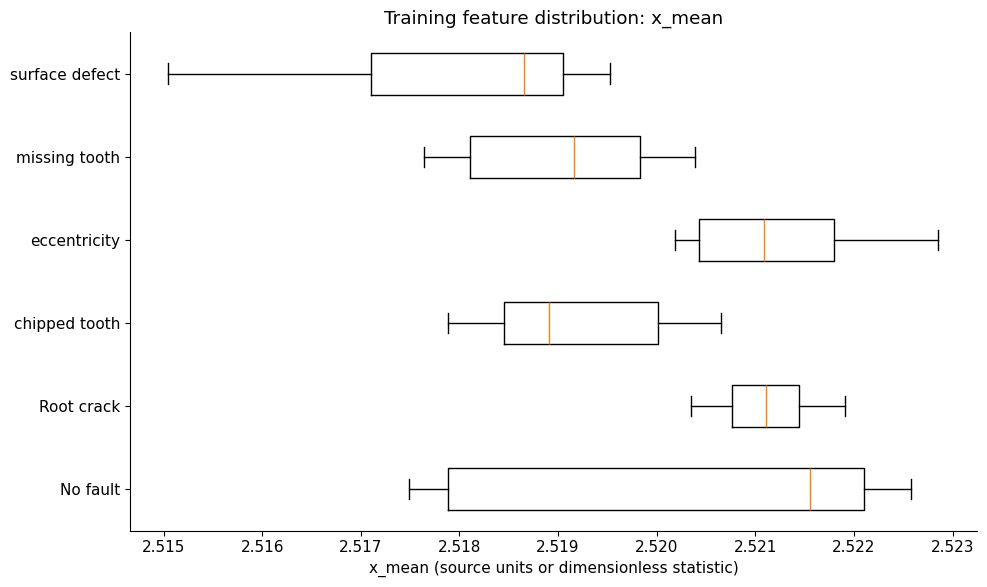

/tmp/ipykernel_586/1076169633.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, vert=False, labels=encoder.classes_, showfliers=False)


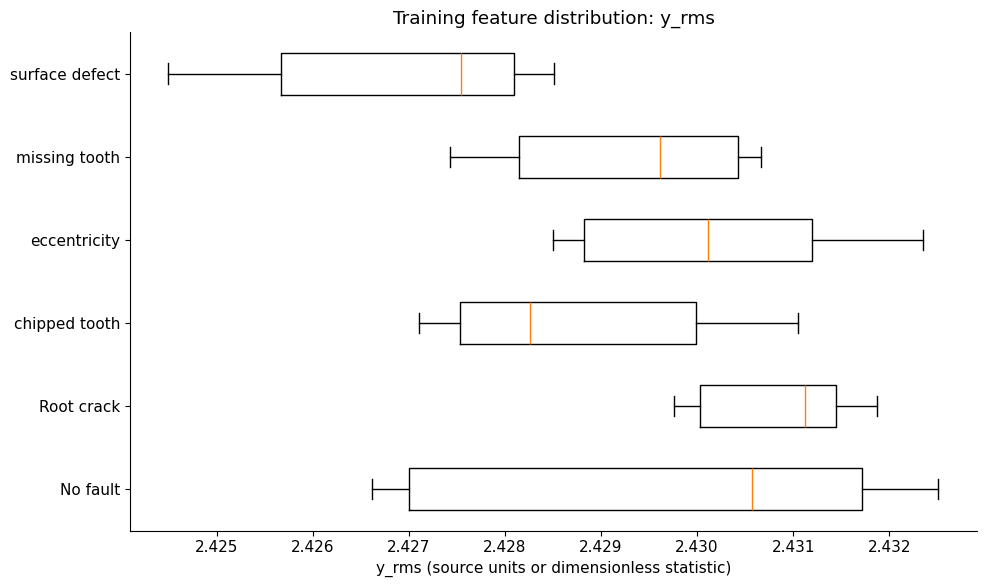

In [10]:
top_features = importance.sort_values('mean_drop', ascending=False)['feature'].head(2).tolist()
train_table = features.loc[features['split'].eq('train')]
for feature in top_features:
    fig, ax = plt.subplots(figsize=(10, 6))
    groups = [train_table.loc[train_table['label'].eq(label), feature] for label in encoder.classes_]
    ax.boxplot(groups, vert=False, labels=encoder.classes_, showfliers=False)
    ax.set(xlabel=f'{feature} (source units or dimensionless statistic)', title=f'Training feature distribution: {feature}')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / (feature + '_distribution.png'), dpi=160)
    plt.show()
